In [ ]:


# CELL 1: Setup & Imports
import os, tarfile, xml.etree.ElementTree as ET
from datetime import datetime
import random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Dense, LSTM, Dropout, LayerNormalization, MultiHeadAttention, GlobalAveragePooling1D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import joblib

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print("TF version:", tf.__version__)

TF version: 2.19.0


In [ ]:
# CELL 2: Extract Archive
FILE_PATH = '/content/drive/MyDrive/abilene-TM.tar.gz'
EXTRACT_PATH = '/content/abilene_data'
os.makedirs(EXTRACT_PATH, exist_ok=True)

print("Extracting", FILE_PATH, "->", EXTRACT_PATH)
with tarfile.open(FILE_PATH, 'r:gz') as tar:
    tar.extractall(path=EXTRACT_PATH)
print("Extraction complete.")

Extracting /content/drive/MyDrive/abilene-TM.tar.gz -> /content/abilene_data


/tmp/ipykernel_5696/1244628904.py:8: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=EXTRACT_PATH)


Extraction complete.


In [ ]:
# CELL 3: Parse Abilene XML Files
def parse_abilene_files(search_path):
    xml_files = []
    for root, _, files in os.walk(search_path):
        for f in files:
            if f.startswith("TM-") and f.endswith(".xml"):
                xml_files.append(os.path.join(root, f))
    xml_files.sort()
    if not xml_files:
        raise FileNotFoundError("No TM-*.xml files found in extraction path.")

    nodes = ['ATLA-M5','ATLAng','CHINng','DNVRng','HSTNng','IPLSng','KSCYng','LOSAng','NYCMng','SNVAng','STTLng','WASHng']
    recs, timestamps = [], []

    for p in xml_files:
        try:
            tree = ET.parse(p)
            root = tree.getroot()
            fname = os.path.basename(p)
            ts_str = fname.replace('TM-','').replace('.xml','')
            try:
                ts = datetime.strptime(ts_str, '%Y-%m-%d-%H%M')
            except:
                ts = ts_str
            tm = np.zeros((12,12), dtype=float)
            intra = root.find('IntraTM')
            if intra is not None:
                for src in intra.findall('src'):
                    s = src.get('id')
                    if s in nodes:
                        i = nodes.index(s)
                        for dst in src.findall('dst'):
                            d = dst.get('id')
                            if d in nodes:
                                j = nodes.index(d)
                                try:
                                    val = dst.text
                                    tm[i,j] = float(val) if val is not None and val.strip() != '' else 0.0
                                except:
                                    tm[i,j] = 0.0
            recs.append(tm.flatten())
            timestamps.append(ts)
        except Exception as e:
            print("Skipping", p, ":", e)
            continue

    cols = [f"{s}->{d}" for s in nodes for d in nodes]
    df = pd.DataFrame(recs, columns=cols, index=pd.to_datetime(timestamps, errors='coerce'))
    df = df.sort_index()
    return df

print("Parsing files...")
df = parse_abilene_files(EXTRACT_PATH)
print("Parsed timesteps:", len(df))
df.head()

Parsing files...
Parsed timesteps: 48096


,ATLA-M5->ATLA-M5,ATLA-M5->ATLAng,ATLA-M5->CHINng,ATLA-M5->DNVRng,ATLA-M5->HSTNng,ATLA-M5->IPLSng,ATLA-M5->KSCYng,ATLA-M5->LOSAng,ATLA-M5->NYCMng,ATLA-M5->SNVAng,...,WASHng->CHINng,WASHng->DNVRng,WASHng->HSTNng,WASHng->IPLSng,WASHng->KSCYng,WASHng->LOSAng,WASHng->NYCMng,WASHng->SNVAng,WASHng->STTLng,WASHng->WASHng
2004-03-01 00:00:00,26.666667,522.208000,1641.338667,335.728000,413.032000,489.874667,365.077333,817.869333,452.061333,747.405333,...,66541.197333,36063.421333,15439.312000,62781.813333,32642.733333,91675.626667,133661.405333,1980.576000,29760.202667,187653.482667
2004-03-01 00:05:00,26.666667,465.701333,868.098667,148.346667,398.701333,1821.269333,402.144000,1090.848000,585.202667,0.000000,...,62246.088000,34109.810667,15664.965333,56823.610667,24912.210667,100567.461333,137277.728000,4411.589333,30667.266667,190925.981333
2004-03-01 00:10:00,53.333333,375.261333,1082.378667,276.136000,453.426667,1703.384000,407.152000,403.664000,853.005333,119.802667,...,70181.930667,29905.896000,19918.581333,58658.568000,19036.714667,92415.480000,153845.554667,5300.653333,39990.880000,218742.773333
2004-03-01 00:15:00,67.274667,498.360000,1332.205333,121.269333,425.168000,794.472000,506.746667,142.328000,818.728000,168.928000,...,74490.416000,44822.789333,16250.042667,50589.922667,18758.725333,97793.093333,159339.533333,4490.272000,38331.688000,265665.077333
2004-03-01 00:20:00,26.666667,723.962667,1428.480000,165.938667,459.965333,403.757333,303.256000,257.877333,848.208000,73.773333,...,69881.266667,44536.856000,18448.840000,51095.165333,18614.133333,93446.560000,151623.424000,3487.808000,43462.373333,210540.786667


In [ ]:
# CELL 4: Drop Self-Links & Add Time Features
nodes = ['ATLA-M5','ATLAng','CHINng','DNVRng','HSTNng','IPLSng','KSCYng','LOSAng','NYCMng','SNVAng','STTLng','WASHng']
diag_cols = [f"{n}->{n}" for n in nodes]
print("Dropping diagonal:", diag_cols)
df = df.drop(columns=diag_cols, errors='ignore')
print("New shape:", df.shape)

times = df.index.to_series()
hour = (times.dt.hour + times.dt.minute/60.0).to_numpy()
dow = times.dt.weekday.to_numpy()

hour_sin = np.sin(2*np.pi*(hour/24.0)).reshape(-1,1)
hour_cos = np.cos(2*np.pi*(hour/24.0)).reshape(-1,1)
dow_sin = np.sin(2*np.pi*(dow/7.0)).reshape(-1,1)
dow_cos = np.cos(2*np.pi*(dow/7.0)).reshape(-1,1)

time_feats = np.concatenate([hour_sin, hour_cos, dow_sin, dow_cos], axis=1)
n_time_feats = time_feats.shape[1]
print("Time features shape:", time_feats.shape)

traffic_array = df.values.copy()
full_raw = np.concatenate([traffic_array, time_feats], axis=1)
print("Full raw shape (traffic + time):", full_raw.shape)

Dropping diagonal: ['ATLA-M5->ATLA-M5', 'ATLAng->ATLAng', 'CHINng->CHINng', 'DNVRng->DNVRng', 'HSTNng->HSTNng', 'IPLSng->IPLSng', 'KSCYng->KSCYng', 'LOSAng->LOSAng', 'NYCMng->NYCMng', 'SNVAng->SNVAng', 'STTLng->STTLng', 'WASHng->WASHng']
New shape: (48096, 132)
Time features shape: (48096, 4)
Full raw shape (traffic + time): (48096, 136)


In [ ]:
# CELL 5: Configuration
USE_LOG = True
PCA_COMPONENTS = 20
SEQ_LEN_RF = 48
SEQ_LEN_LSTM = 48
SEQ_LEN_TRANSFORMER = 48
TRAIN_RATIO = 0.8
BATCH_SIZE = 64
EPOCHS = 60
RF_N_ESTIMATORS = 100
OUT_DIR = '/content/abilene_experiments'
os.makedirs(OUT_DIR, exist_ok=True)

print(f"Config: USE_LOG={USE_LOG}, PCA={PCA_COMPONENTS}")
print(f"Seq lengths: RF={SEQ_LEN_RF}, LSTM={SEQ_LEN_LSTM}, Transformer={SEQ_LEN_TRANSFORMER}")
print(f"RF trees: {RF_N_ESTIMATORS}")

Config: USE_LOG=True, PCA=20
Seq lengths: RF=48, LSTM=48, Transformer=48
RF trees: 100


In [ ]:
# CELL 6: Common Preprocessing
T = len(full_raw)
train_cut = int(T * TRAIN_RATIO)
n_traffic = df.shape[1]
print(f"Total Timesteps: {T}, Training Cut: {train_cut}")


raw = full_raw.copy()
if USE_LOG:
    raw[:, :n_traffic] = np.clip(raw[:, :n_traffic], a_min=0, a_max=None)
    raw[:, :n_traffic] = np.log1p(raw[:, :n_traffic])


scaler = MinMaxScaler(feature_range=(0,1))
scaler.fit(raw[:train_cut])
scaled_all = scaler.transform(raw)


traffic_scaled = scaled_all[:, :n_traffic]
time_scaled = scaled_all[:, n_traffic:]

pca = PCA(n_components=PCA_COMPONENTS, random_state=SEED)
pca.fit(traffic_scaled[:train_cut])
traffic_pcs = pca.transform(traffic_scaled)

# 4. Combine PCA components with time features
proc_all = np.concatenate([traffic_pcs, time_scaled], axis=1)
print("Preprocessing Complete.")
print(f"Traffic scaled: {traffic_scaled.shape}, PCA reduced: {traffic_pcs.shape}")
print(f"Combined proc_all: {proc_all.shape}")

# Save preprocessing objects
joblib.dump(scaler, os.path.join(OUT_DIR, 'scaler.pkl'))
joblib.dump(pca, os.path.join(OUT_DIR, 'pca.pkl'))

Total Timesteps: 48096, Training Cut: 38476
Preprocessing Complete.
Traffic scaled: (48096, 132), PCA reduced: (48096, 20)
Combined proc_all: (48096, 24)


['/content/abilene_experiments/pca.pkl']

In [ ]:
# CELL 7: Prepare Data for All Three Models

#RF Data
print(f"Generating RF sequences with length: {SEQ_LEN_RF}...")
X_rf, y_rf = [], []
for i in range(len(proc_all) - SEQ_LEN_RF):
    X_rf.append(proc_all[i : i + SEQ_LEN_RF].flatten())
    y_rf.append(traffic_pcs[i + SEQ_LEN_RF])
X_rf = np.array(X_rf)
y_rf = np.array(y_rf)

train_seq_cnt_rf = max(0, train_cut - SEQ_LEN_RF)
X_train_rf, X_test_rf = X_rf[:train_seq_cnt_rf], X_rf[train_seq_cnt_rf:]
y_train_rf, y_test_rf = y_rf[:train_seq_cnt_rf], y_rf[train_seq_cnt_rf:]
print(f"RF Data: X_train={X_train_rf.shape}, X_test={X_test_rf.shape}")

# LSTM Data
print(f"Generating LSTM sequences with length: {SEQ_LEN_LSTM}...")
X_lstm, y_lstm = [], []
for i in range(len(proc_all) - SEQ_LEN_LSTM):
    X_lstm.append(proc_all[i : i + SEQ_LEN_LSTM])
    y_lstm.append(traffic_pcs[i + SEQ_LEN_LSTM])
X_lstm = np.array(X_lstm)
y_lstm = np.array(y_lstm)

train_seq_cnt_lstm = max(0, train_cut - SEQ_LEN_LSTM)
X_train_lstm, X_test_lstm = X_lstm[:train_seq_cnt_lstm], X_lstm[train_seq_cnt_lstm:]
y_train_lstm, y_test_lstm = y_lstm[:train_seq_cnt_lstm], y_lstm[train_seq_cnt_lstm:]
print(f"LSTM Data: X_train={X_train_lstm.shape}, X_test={X_test_lstm.shape}")

# Transformer Data
print(f"Generating Transformer sequences with length: {SEQ_LEN_TRANSFORMER}...")
X_transformer, y_transformer = [], []
for i in range(len(proc_all) - SEQ_LEN_TRANSFORMER):
    X_transformer.append(proc_all[i : i + SEQ_LEN_TRANSFORMER])
    y_transformer.append(traffic_pcs[i + SEQ_LEN_TRANSFORMER])
X_transformer = np.array(X_transformer)
y_transformer = np.array(y_transformer)

train_seq_cnt_transformer = max(0, train_cut - SEQ_LEN_TRANSFORMER)
X_train_transformer, X_test_transformer = X_transformer[:train_seq_cnt_transformer], X_transformer[train_seq_cnt_transformer:]
y_train_transformer, y_test_transformer = y_transformer[:train_seq_cnt_transformer], y_transformer[train_seq_cnt_transformer:]
print(f"Transformer Data: X_train={X_train_transformer.shape}, X_test={X_test_transformer.shape}")

Generating RF sequences with length: 48...
RF Data: X_train=(38428, 1152), X_test=(9620, 1152)
Generating LSTM sequences with length: 48...
LSTM Data: X_train=(38428, 48, 24), X_test=(9620, 48, 24)
Generating Transformer sequences with length: 48...
Transformer Data: X_train=(38428, 48, 24), X_test=(9620, 48, 24)


In [ ]:
# CELL 8: Inverse Transform Function
def inverse_transform_preds_from_pca(preds_pca, y_pca, scaler, pca, n_traffic, n_time_feats, use_log):
    preds_scaled_traffic = pca.inverse_transform(preds_pca)
    y_scaled_traffic = pca.inverse_transform(y_pca)

    zeros_time = np.zeros((preds_scaled_traffic.shape[0], n_time_feats))
    preds_full_scaled = np.concatenate([preds_scaled_traffic, zeros_time], axis=1)
    y_full_scaled = np.concatenate([y_scaled_traffic, zeros_time], axis=1)

    preds_full = scaler.inverse_transform(preds_full_scaled)
    y_full = scaler.inverse_transform(y_full_scaled)

    preds_traffic = preds_full[:, :n_traffic]
    y_traffic = y_full[:, :n_traffic]

    if use_log:
        preds_traffic = np.expm1(preds_traffic)
        y_traffic = np.expm1(y_traffic)

    return preds_traffic, y_traffic

In [ ]:
# CELL 9: Build LSTM Model
def build_lstm_model(seq_len, n_features, out_dim, units=(128,64), dropout=0.2):
    inp = Input(shape=(seq_len, n_features))
    x = LSTM(units[0], return_sequences=True)(inp)
    x = Dropout(dropout)(x)
    x = LSTM(units[1], return_sequences=False)(x)
    x = Dropout(dropout)(x)
    out = Dense(out_dim, activation='linear')(x)
    model = Model(inputs=inp, outputs=out)
    return model

n_input_features = X_train_lstm.shape[2]
model_lstm = build_lstm_model(SEQ_LEN_LSTM, n_input_features, PCA_COMPONENTS)
model_lstm.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 48, 24)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 48, 128)        │        78,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 20)             │         1,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129,044 (504.08 KB)

 Trainable params: 129,044 (504.08 KB)

 Non-trainable params: 0 (0.00 B)


TRAINING LSTM MODEL
Epoch 1/60

Epoch 1: val_loss improved from None to 0.01244, saving model to /content/abilene_experiments/lstm_best.keras

Epoch 1: finished saving model to /content/abilene_experiments/lstm_best.keras
601/601 - 13s - 22ms/step - loss: 0.0212 - mae: 0.1545 - val_loss: 0.0124 - val_mae: 0.1228 - learning_rate: 1.0000e-04
Epoch 2/60

Epoch 2: val_loss improved from 0.01244 to 0.01096, saving model to /content/abilene_experiments/lstm_best.keras

Epoch 2: finished saving model to /content/abilene_experiments/lstm_best.keras
601/601 - 7s - 12ms/step - loss: 0.0143 - mae: 0.1309 - val_loss: 0.0110 - val_mae: 0.1144 - learning_rate: 1.0000e-04
Epoch 3/60

Epoch 3: val_loss improved from 0.01096 to 0.01048, saving model to /content/abilene_experiments/lstm_best.keras

Epoch 3: finished saving model to /content/abilene_experiments/lstm_best.keras
601/601 - 6s - 10ms/step - loss: 0.0131 - mae: 0.1247 - val_loss: 0.0105 - val_mae: 0.1114 - learning_rate: 1.0000e-04
Epoch 4/6

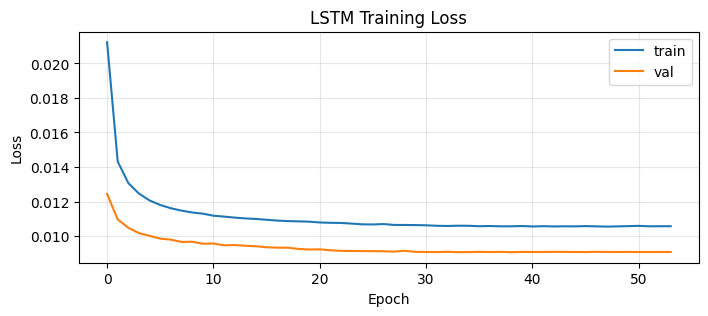

In [ ]:
# CELL 10: Train LSTM Model
print("\n" + "="*60)
print("TRAINING LSTM MODEL")
print("="*60)

model_lstm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4, clipnorm=1.0),
    loss='huber',
    metrics=['mae']
)

ckpt_path_lstm = os.path.join(OUT_DIR, 'lstm_best.keras')
callbacks_lstm = [
    ModelCheckpoint(ckpt_path_lstm, save_best_only=True, monitor='val_loss', verbose=1),
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1)
]

history_lstm = model_lstm.fit(
    X_train_lstm, y_train_lstm,
    validation_data=(X_test_lstm, y_test_lstm),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_lstm,
    verbose=2
)

plt.figure(figsize=(8,3))
plt.plot(history_lstm.history['loss'], label='train')
plt.plot(history_lstm.history['val_loss'], label='val')
plt.legend()
plt.title('LSTM Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# CELL 11: Build Transformer Model
def get_positional_encoding(seq_len, d_model):
    pos = np.arange(seq_len)[:, np.newaxis]
    i = np.arange(d_model)[np.newaxis, :]
    angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
    angle_rads = pos * angle_rates
    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])
    pos_encoding = angle_rads[np.newaxis, ...]
    return tf.cast(pos_encoding, dtype=tf.float32)

def build_transformer(seq_len, n_features, out_dim, d_model=96, n_heads=6, n_layers=3, dropout=0.25):
    inputs = Input(shape=(seq_len, n_features))


    x = Dense(d_model)(inputs)


    pe = get_positional_encoding(seq_len, d_model)
    x = x + pe[:, :seq_len, :]


    for _ in range(n_layers):
        attn_out = MultiHeadAttention(
            num_heads=n_heads,
            key_dim=d_model // n_heads,
            dropout=dropout
        )(x, x)
        x = LayerNormalization(epsilon=1e-6)(x + attn_out)

        ff = Dense(d_model * 4, activation='gelu')(x)
        ff = Dense(d_model)(ff)
        ff = Dropout(dropout)(ff)
        x = LayerNormalization(epsilon=1e-6)(x + ff)

    # Aggregate sequence
    x = GlobalAveragePooling1D()(x)

    # Output
    outputs = Dense(out_dim, activation='linear')(x)

    model = Model(inputs, outputs)
    return model

n_input_features_transformer = X_train_transformer.shape[2]
model_transformer = build_transformer(
    SEQ_LEN_TRANSFORMER,
    n_input_features_transformer,
    PCA_COMPONENTS,
    d_model=96,
    n_heads=6,
    n_layers=3,
    dropout=0.25
)
model_transformer.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 48, 24)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 48, 96)    │      2,400 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 48, 96)    │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 48, 96)    │     37,248 │ add[0][0],        │
│ (MultiHeadAttentio… │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 48, 96)    │          0 │ add[0][0],        │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 48, 96)    │        192 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 48, 384)   │     37,248 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 48, 96)    │     36,960 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 48, 96)    │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 48, 96)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 48, 96)    │        192 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 48, 96)    │     37,248 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 48, 96)    │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 48, 96)    │        192 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 48, 384)   │     37,248 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 48, 96)    │     36,960 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 48, 96)    │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 48, 96)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 48, 96)    │        192 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 339,860 (1.30 MB)

 Trainable params: 339,860 (1.30 MB)

 Non-trainable params: 0 (0.00 B)


TRAINING TRANSFORMER MODEL
Epoch 1/60

Epoch 1: val_loss improved from None to 0.02472, saving model to /content/abilene_experiments/transformer_best.keras

Epoch 1: finished saving model to /content/abilene_experiments/transformer_best.keras
601/601 - 40s - 67ms/step - loss: 0.1413 - mae: 0.3714 - val_loss: 0.0247 - val_mae: 0.1740
Epoch 2/60

Epoch 2: val_loss improved from 0.02472 to 0.01566, saving model to /content/abilene_experiments/transformer_best.keras

Epoch 2: finished saving model to /content/abilene_experiments/transformer_best.keras
601/601 - 7s - 12ms/step - loss: 0.0195 - mae: 0.1524 - val_loss: 0.0157 - val_mae: 0.1375
Epoch 3/60

Epoch 3: val_loss improved from 0.01566 to 0.01339, saving model to /content/abilene_experiments/transformer_best.keras

Epoch 3: finished saving model to /content/abilene_experiments/transformer_best.keras
601/601 - 6s - 11ms/step - loss: 0.0157 - mae: 0.1364 - val_loss: 0.0134 - val_mae: 0.1262
Epoch 4/60

Epoch 4: val_loss improved from 

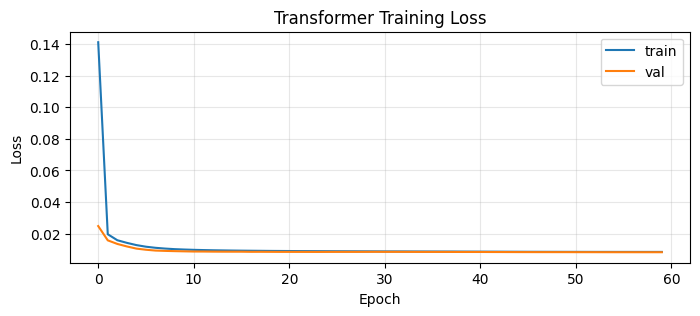

In [ ]:
# CELL 12: Train Transformer Model
print("\n" + "="*60)
print("TRAINING TRANSFORMER MODEL")
print("="*60)

class WarmupCosineSchedule(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, init_lr, warmup_steps, total_steps):
        super().__init__()
        self.init_lr = float(init_lr)
        self.warmup_steps = float(warmup_steps)
        self.total_steps = float(total_steps)

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        warmup_lr = self.init_lr * step / tf.maximum(1.0, self.warmup_steps)
        cosine_steps = tf.maximum(1.0, self.total_steps - self.warmup_steps)
        cosine_lr = 0.5 * self.init_lr * (
            1 + tf.cos(np.pi * (step - self.warmup_steps) / cosine_steps)
        )
        return tf.where(step < self.warmup_steps, warmup_lr, cosine_lr)

    def get_config(self):
        return {
            "init_lr": self.init_lr,
            "warmup_steps": self.warmup_steps,
            "total_steps": self.total_steps
        }

steps_per_epoch = max(1, len(X_train_transformer) // BATCH_SIZE)
total_steps = steps_per_epoch * EPOCHS
warmup_steps = min(1000, total_steps // 5)

lr_schedule = WarmupCosineSchedule(
    init_lr=5e-5,
    warmup_steps=warmup_steps,
    total_steps=total_steps
)

model_transformer.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule, clipnorm=1.0),
    loss='huber',
    metrics=['mae']
)

ckpt_path_transformer = os.path.join(OUT_DIR, 'transformer_best.keras')
callbacks_transformer = [
    ModelCheckpoint(ckpt_path_transformer, monitor='val_loss', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
]

history_transformer = model_transformer.fit(
    X_train_transformer, y_train_transformer,
    validation_data=(X_test_transformer, y_test_transformer),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_transformer,
    verbose=2
)

plt.figure(figsize=(8,3))
plt.plot(history_transformer.history['loss'], label='train')
plt.plot(history_transformer.history['val_loss'], label='val')
plt.legend()
plt.title('Transformer Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(alpha=0.3)
plt.show()

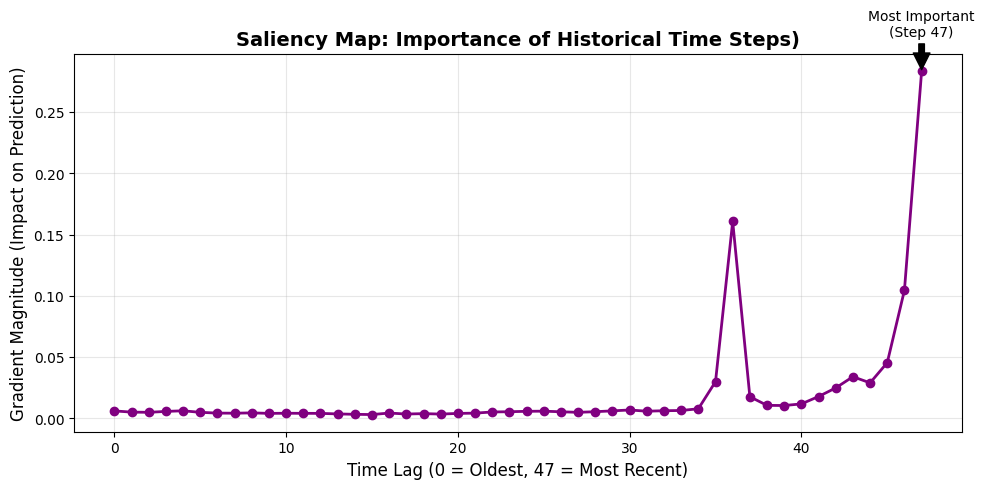

In [ ]:

# CELL: Saliency Map (Feature Importance)

import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os

# Output directory (same pattern as other plots)
OUT_DIR = "./figures"
os.makedirs(OUT_DIR, exist_ok=True)

# 1. Select a sample from the test set
sample_idx = 0  # Change this to see different samples
x_sample = X_test_transformer[sample_idx:sample_idx+1]
x_tensor = tf.convert_to_tensor(x_sample, dtype=tf.float32)

# 2. Calculate Gradients (Sensitivity)
with tf.GradientTape() as tape:
    tape.watch(x_tensor)
    preds = model_transformer(x_tensor)
    # Explain overall prediction magnitude (sum of PCA components)
    target = tf.reduce_sum(preds)

# Get gradient of the output w.r.t the input
grads = tape.gradient(target, x_tensor)

# 3. Process gradients to get importance per time step
# Shape: (1, 48, n_features) -> (48,)
d_grad_abs = tf.abs(grads)
time_step_importance = tf.reduce_mean(d_grad_abs, axis=-1)[0].numpy()

# 4. Plot saliency map
plt.figure(figsize=(10, 5))
plt.plot(time_step_importance, color='purple', marker='o', linewidth=2)
plt.title(f'Saliency Map: Importance of Historical Time Steps)',
          fontsize=14, fontweight='bold')
plt.xlabel('Time Lag (0 = Oldest, 47 = Most Recent)', fontsize=12)
plt.ylabel('Gradient Magnitude (Impact on Prediction)', fontsize=12)
plt.grid(True, alpha=0.3)

# Highlight the most important timestep
max_idx = np.argmax(time_step_importance)
plt.annotate(f'Most Important\n(Step {max_idx})',
             xy=(max_idx, time_step_importance[max_idx]),
             xytext=(max_idx, time_step_importance[max_idx] * 1.1),
             arrowprops=dict(facecolor='black', shrink=0.05),
             ha='center')

plt.tight_layout()

# 5. Save figure
filename = f"saliency_map_sample_{sample_idx}.png"
plt.savefig(os.path.join(OUT_DIR, filename),
            dpi=150, bbox_inches='tight')

plt.show()


In [ ]:
# CELL 13: Train Random Forest Model
print("\n" + "="*60)
print("TRAINING RANDOM FOREST MODEL")
print("="*60)

rf = RandomForestRegressor(
    n_estimators=RF_N_ESTIMATORS,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)

start = time.time()
rf.fit(X_train_rf, y_train_rf)
print(f"RF trained in {time.time() - start:.1f}s")

joblib.dump(rf, os.path.join(OUT_DIR, 'rf_multioutput.pkl'))


TRAINING RANDOM FOREST MODEL


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  3.0min finished


RF trained in 182.2s


['./figures/rf_multioutput.pkl']

In [ ]:
# CELL 14: Generate Predictions for All Models
print("\n" + "="*60)
print("GENERATING PREDICTIONS")
print("="*60)

# LSTM predictions
preds_lstm_pca = model_lstm.predict(X_test_lstm, verbose=0)
preds_lstm_actual, y_test_lstm_actual = inverse_transform_preds_from_pca(
    preds_lstm_pca, y_test_lstm, scaler, pca, n_traffic, n_time_feats, USE_LOG
)

# Transformer predictions
preds_transformer_pca = model_transformer.predict(X_test_transformer, verbose=0)
preds_transformer_actual, y_test_transformer_actual = inverse_transform_preds_from_pca(
    preds_transformer_pca, y_test_transformer, scaler, pca, n_traffic, n_time_feats, USE_LOG
)

# RF predictions
preds_rf_pca = rf.predict(X_test_rf)
preds_rf_actual, y_test_rf_actual = inverse_transform_preds_from_pca(
    preds_rf_pca, y_test_rf, scaler, pca, n_traffic, n_time_feats, USE_LOG
)

print(f"LSTM predictions: {preds_lstm_actual.shape}")
print(f"Transformer predictions: {preds_transformer_actual.shape}")
print(f"RF predictions: {preds_rf_actual.shape}")


GENERATING PREDICTIONS


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.2s


LSTM predictions: (9620, 132)
Transformer predictions: (9620, 132)
RF predictions: (9620, 132)


[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.4s finished


In [ ]:
# CELL 15: Align Predictions for Fair Comparison
# Use the model with the longest sequence (LSTM/Transformer) as baseline
# All models predict SEQ_LEN steps into the future from start of test set

# Find the minimum test size (most restrictive model)
min_test_size = min(
    preds_lstm_actual.shape[0],
    preds_transformer_actual.shape[0],
    preds_rf_actual.shape[0]
)

# Truncate all to same size for fair comparison
preds_lstm_aligned = preds_lstm_actual[:min_test_size]
preds_transformer_aligned = preds_transformer_actual[:min_test_size]
preds_rf_aligned = preds_rf_actual[:min_test_size]
y_test_aligned = y_test_lstm_actual[:min_test_size]  # Use LSTM's y_test as reference

print(f"\nAligned predictions for comparison: {min_test_size} timesteps")

# Persistence baseline (predict t-1 as t)
y_true_sliced = y_test_aligned[1:]
preds_persist = y_test_aligned[:-1]
preds_lstm_sliced = preds_lstm_aligned[1:]
preds_transformer_sliced = preds_transformer_aligned[1:]
preds_rf_sliced = preds_rf_aligned[1:]

print(f"After persistence alignment: {len(y_true_sliced)} timesteps")


Aligned predictions for comparison: 9620 timesteps
After persistence alignment: 9619 timesteps


In [ ]:
# CELL 16: Calculate Overall Metrics
def metrics_summary(y_true, y_pred):
    y_t, y_p = y_true.flatten(), y_pred.flatten()
    rmse = np.sqrt(mean_squared_error(y_t, y_p))
    mae = mean_absolute_error(y_t, y_p)
    return rmse, mae

# Calculate metrics for each model
p_rmse, p_mae = metrics_summary(y_true_sliced, preds_persist)
l_rmse, l_mae = metrics_summary(y_true_sliced, preds_lstm_sliced)
t_rmse, t_mae = metrics_summary(y_true_sliced, preds_transformer_sliced)
r_rmse, r_mae = metrics_summary(y_true_sliced, preds_rf_sliced)

results = pd.DataFrame([
    {'model': 'Persistence (Baseline)', 'rmse': p_rmse, 'mae': p_mae},
    {'model': 'LSTM', 'rmse': l_rmse, 'mae': l_mae},
    {'model': 'Transformer', 'rmse': t_rmse, 'mae': t_mae},
    {'model': 'Random Forest', 'rmse': r_rmse, 'mae': r_mae}
])

results = results.sort_values('rmse').reset_index(drop=True)

print("\n" + "="*60)
print("OVERALL PERFORMANCE COMPARISON")
print("="*60)
display(results)

# Check improvement over baseline
best_model_name = results.iloc[0]['model']
baseline_rmse = results.loc[results['model']=='Persistence (Baseline)', 'rmse'].values[0]
best_rmse = results.iloc[0]['rmse']

if 'Baseline' in best_model_name:
    print("\n⚠️ CRITICAL: The Naive Baseline is winning. Models are not learning effectively.")
else:
    improv = (baseline_rmse - best_rmse) / baseline_rmse * 100
    print(f"\n✅ SUCCESS: {best_model_name} beats baseline by {improv:.2f}%")

# Save results
results.to_csv(os.path.join(OUT_DIR, 'overall_comparison.csv'), index=False)


OVERALL PERFORMANCE COMPARISON


,model,rmse,mae
0,Transformer,3782.025313,1746.156661
1,LSTM,4096.461736,1884.315200
2,Persistence (Baseline),4216.624240,1959.346192
3,Random Forest,6924.700032,3081.295047



✅ SUCCESS: Transformer beats baseline by 10.31%


In [ ]:
# CELL 17: Per-Link Analysis
print("\n" + "="*60)
print("PER-LINK ANALYSIS")
print("="*60)

# Calculate RMSE for each link
l_link_rmse = np.sqrt(np.mean((preds_lstm_sliced - y_true_sliced)**2, axis=0))
t_link_rmse = np.sqrt(np.mean((preds_transformer_sliced - y_true_sliced)**2, axis=0))
r_link_rmse = np.sqrt(np.mean((preds_rf_sliced - y_true_sliced)**2, axis=0))

links = df.columns.tolist()
comp_df = pd.DataFrame({
    'link': links,
    'lstm_rmse': l_link_rmse,
    'transformer_rmse': t_link_rmse,
    'rf_rmse': r_link_rmse
})

# Determine best model per link
comp_df['best_model'] = comp_df[['lstm_rmse', 'transformer_rmse', 'rf_rmse']].idxmin(axis=1).str.replace('_rmse', '').str.upper()

# Count wins
lstm_wins = (comp_df['best_model'] == 'LSTM').sum()
transformer_wins = (comp_df['best_model'] == 'TRANSFORMER').sum()
rf_wins = (comp_df['best_model'] == 'RF').sum()

print(f"\nModel Performance by Link:")
print(f"LSTM wins: {lstm_wins}/{len(comp_df)} links")
print(f"Transformer wins: {transformer_wins}/{len(comp_df)} links")
print(f"Random Forest wins: {rf_wins}/{len(comp_df)} links")

# Top 8 best/worst links for each model
print("\n--- Top 8 BEST Links (Lowest LSTM Error) ---")
display(comp_df.sort_values('lstm_rmse').head(8)[['link', 'lstm_rmse', 'transformer_rmse', 'rf_rmse', 'best_model']])

print("\n--- Top 8 WORST Links (Highest LSTM Error) ---")
display(comp_df.sort_values('lstm_rmse', ascending=False).head(8)[['link', 'lstm_rmse', 'transformer_rmse', 'rf_rmse', 'best_model']])

print("\n--- Top 8 BEST Links (Lowest Transformer Error) ---")
display(comp_df.sort_values('transformer_rmse').head(8)[['link', 'lstm_rmse', 'transformer_rmse', 'rf_rmse', 'best_model']])

print("\n--- Top 8 WORST Links (Highest Transformer Error) ---")
display(comp_df.sort_values('transformer_rmse', ascending=False).head(8)[['link', 'lstm_rmse', 'transformer_rmse', 'rf_rmse', 'best_model']])

# Save per-link comparison
comp_df.to_csv(os.path.join(OUT_DIR, 'per_link_comparison_all_models.csv'), index=False)
print(f"\nSaved per-link comparison to {OUT_DIR}")


PER-LINK ANALYSIS

Model Performance by Link:
LSTM wins: 7/132 links
Transformer wins: 125/132 links
Random Forest wins: 0/132 links

--- Top 8 BEST Links (Lowest LSTM Error) ---


,link,lstm_rmse,transformer_rmse,rf_rmse,best_model
99,SNVAng->ATLA-M5,14.584536,14.056470,14.854209,TRANSFORMER
103,SNVAng->HSTNng,66.275008,60.627308,113.987673,TRANSFORMER
6,ATLA-M5->LOSAng,70.662976,64.774169,95.257163,TRANSFORMER
1,ATLA-M5->CHINng,95.607167,86.236812,124.119321,TRANSFORMER
109,SNVAng->WASHng,100.617980,97.541290,184.830508,TRANSFORMER
8,ATLA-M5->SNVAng,105.162244,101.277328,111.102319,TRANSFORMER
33,DNVRng->ATLA-M5,113.433073,96.131744,196.813677,TRANSFORMER
3,ATLA-M5->HSTNng,119.412930,93.212981,144.127750,TRANSFORMER



--- Top 8 WORST Links (Highest LSTM Error) ---


,link,lstm_rmse,transformer_rmse,rf_rmse,best_model
129,WASHng->NYCMng,21650.626228,17947.423540,43147.472427,TRANSFORMER
124,WASHng->DNVRng,15498.282548,15031.450722,27544.891048,TRANSFORMER
128,WASHng->LOSAng,15066.281617,14096.588967,20997.832015,TRANSFORMER
79,LOSAng->CHINng,13943.964597,13577.462534,18514.932391,TRANSFORMER
95,NYCMng->LOSAng,10803.915881,10025.799659,15324.540476,TRANSFORMER
28,CHINng->LOSAng,8627.392994,8221.699217,12298.112358,TRANSFORMER
98,NYCMng->WASHng,7369.927966,6905.687445,9726.660643,TRANSFORMER
87,LOSAng->WASHng,7297.306991,7135.652487,12226.484313,TRANSFORMER



--- Top 8 BEST Links (Lowest Transformer Error) ---


,link,lstm_rmse,transformer_rmse,rf_rmse,best_model
99,SNVAng->ATLA-M5,14.584536,14.056470,14.854209,TRANSFORMER
103,SNVAng->HSTNng,66.275008,60.627308,113.987673,TRANSFORMER
6,ATLA-M5->LOSAng,70.662976,64.774169,95.257163,TRANSFORMER
1,ATLA-M5->CHINng,95.607167,86.236812,124.119321,TRANSFORMER
3,ATLA-M5->HSTNng,119.412930,93.212981,144.127750,TRANSFORMER
33,DNVRng->ATLA-M5,113.433073,96.131744,196.813677,TRANSFORMER
109,SNVAng->WASHng,100.617980,97.541290,184.830508,TRANSFORMER
8,ATLA-M5->SNVAng,105.162244,101.277328,111.102319,TRANSFORMER



--- Top 8 WORST Links (Highest Transformer Error) ---


,link,lstm_rmse,transformer_rmse,rf_rmse,best_model
129,WASHng->NYCMng,21650.626228,17947.423540,43147.472427,TRANSFORMER
124,WASHng->DNVRng,15498.282548,15031.450722,27544.891048,TRANSFORMER
128,WASHng->LOSAng,15066.281617,14096.588967,20997.832015,TRANSFORMER
79,LOSAng->CHINng,13943.964597,13577.462534,18514.932391,TRANSFORMER
95,NYCMng->LOSAng,10803.915881,10025.799659,15324.540476,TRANSFORMER
28,CHINng->LOSAng,8627.392994,8221.699217,12298.112358,TRANSFORMER
87,LOSAng->WASHng,7297.306991,7135.652487,12226.484313,TRANSFORMER
98,NYCMng->WASHng,7369.927966,6905.687445,9726.660643,TRANSFORMER



Saved per-link comparison to ./figures



ERROR DISTRIBUTION ANALYSIS


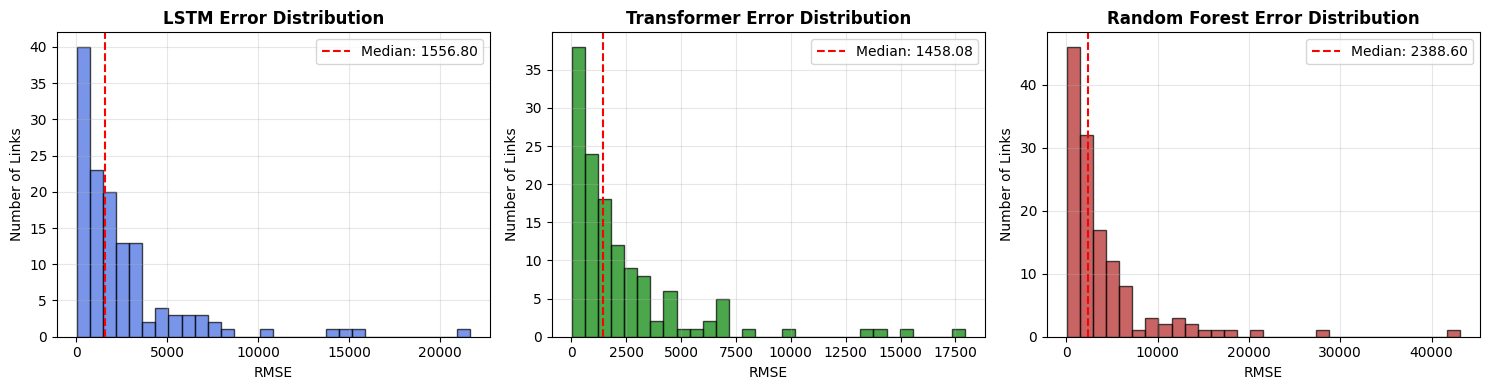

In [ ]:
# CELL 18: Error Distribution Visualization
print("\n" + "="*60)
print("ERROR DISTRIBUTION ANALYSIS")
print("="*60)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(comp_df['lstm_rmse'], bins=30, color='royalblue', alpha=0.7, edgecolor='black')
axes[0].set_title('LSTM Error Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('RMSE')
axes[0].set_ylabel('Number of Links')
axes[0].grid(True, alpha=0.3)
axes[0].axvline(comp_df['lstm_rmse'].median(), color='red', linestyle='--', label=f"Median: {comp_df['lstm_rmse'].median():.2f}")
axes[0].legend()

axes[1].hist(comp_df['transformer_rmse'], bins=30, color='green', alpha=0.7, edgecolor='black')
axes[1].set_title('Transformer Error Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('RMSE')
axes[1].set_ylabel('Number of Links')
axes[1].grid(True, alpha=0.3)
axes[1].axvline(comp_df['transformer_rmse'].median(), color='red', linestyle='--', label=f"Median: {comp_df['transformer_rmse'].median():.2f}")
axes[1].legend()

axes[2].hist(comp_df['rf_rmse'], bins=30, color='firebrick', alpha=0.7, edgecolor='black')
axes[2].set_title('Random Forest Error Distribution', fontsize=12, fontweight='bold')
axes[2].set_xlabel('RMSE')
axes[2].set_ylabel('Number of Links')
axes[2].grid(True, alpha=0.3)
axes[2].axvline(comp_df['rf_rmse'].median(), color='red', linestyle='--', label=f"Median: {comp_df['rf_rmse'].median():.2f}")
axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'error_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_5696/3420824402.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(error_data, labels=['LSTM', 'Transformer', 'Random Forest'],


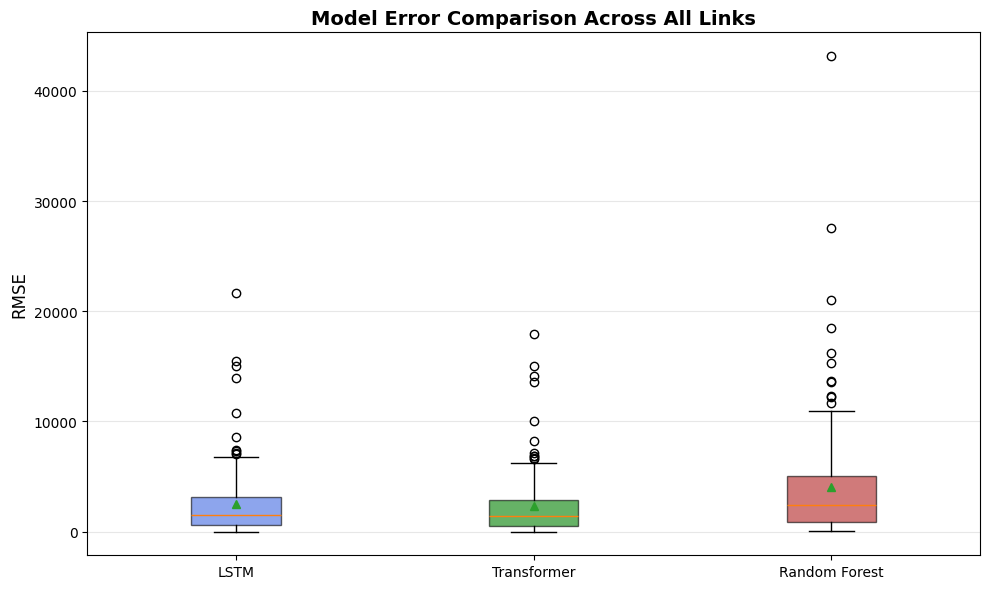

In [ ]:
# CELL 19: Box Plot Comparison
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

error_data = [comp_df['lstm_rmse'], comp_df['transformer_rmse'], comp_df['rf_rmse']]
box = ax.boxplot(error_data, labels=['LSTM', 'Transformer', 'Random Forest'],
                  patch_artist=True, showmeans=True)

colors = ['royalblue', 'green', 'firebrick']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_ylabel('RMSE', fontsize=12)
ax.set_title('Model Error Comparison Across All Links', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'boxplot_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# CELL 20: Select Representative Links for Visualization
# Calculate mean volume to filter active links
mean_volume = np.mean(y_true_sliced, axis=0)
traffic_threshold = np.percentile(mean_volume, 50)  # Top 50% busiest

# Filter active links
busy_indices = [i for i in range(len(links)) if mean_volume[i] > traffic_threshold]

# Sort busy links by LSTM MAE
l_mae_per_link = np.mean(np.abs(preds_lstm_sliced - y_true_sliced), axis=0)
busy_indices_sorted = sorted(busy_indices, key=lambda i: l_mae_per_link[i])

# Select representative links
best_idx = busy_indices_sorted[0]
median_idx = busy_indices_sorted[len(busy_indices_sorted)//2]
worst_idx = busy_indices_sorted[-1]

best_link = links[best_idx]
median_link = links[median_idx]
worst_link = links[worst_idx]

print("\n" + "="*60)
print("SELECTED REPRESENTATIVE LINKS (ACTIVE TRAFFIC ONLY)")
print("="*60)
print(f"Best (Lowest Error):   {best_link}")
print(f"  LSTM RMSE: {comp_df.iloc[best_idx]['lstm_rmse']:.2f}")
print(f"  Transformer RMSE: {comp_df.iloc[best_idx]['transformer_rmse']:.2f}")
print(f"  RF RMSE: {comp_df.iloc[best_idx]['rf_rmse']:.2f}")
print(f"  Avg Traffic: {mean_volume[best_idx]:.0f}")

print(f"\nMedian:                {median_link}")
print(f"  LSTM RMSE: {comp_df.iloc[median_idx]['lstm_rmse']:.2f}")
print(f"  Transformer RMSE: {comp_df.iloc[median_idx]['transformer_rmse']:.2f}")
print(f"  RF RMSE: {comp_df.iloc[median_idx]['rf_rmse']:.2f}")
print(f"  Avg Traffic: {mean_volume[median_idx]:.0f}")

print(f"\nWorst (Highest Error): {worst_link}")
print(f"  LSTM RMSE: {comp_df.iloc[worst_idx]['lstm_rmse']:.2f}")
print(f"  Transformer RMSE: {comp_df.iloc[worst_idx]['transformer_rmse']:.2f}")
print(f"  RF RMSE: {comp_df.iloc[worst_idx]['rf_rmse']:.2f}")
print(f"  Avg Traffic: {mean_volume[worst_idx]:.0f}")


SELECTED REPRESENTATIVE LINKS (ACTIVE TRAFFIC ONLY)
Best (Lowest Error):   STTLng->ATLAng
  LSTM RMSE: 759.62
  Transformer RMSE: 652.17
  RF RMSE: 1256.87
  Avg Traffic: 10117

Median:                LOSAng->DNVRng
  LSTM RMSE: 2968.51
  Transformer RMSE: 2821.91
  RF RMSE: 4292.11
  Avg Traffic: 12886

Worst (Highest Error): WASHng->NYCMng
  LSTM RMSE: 21650.63
  Transformer RMSE: 17947.42
  RF RMSE: 43147.47
  Avg Traffic: 178346


In [ ]:
# CELL 21: Visualization Function for Traffic Predictions (Actual vs Predicted only)
def visualize_traffic_comparison(link_name, link_idx, steps=300, save=True):
    """
    Visualize actual vs predicted traffic for all three models
    (Absolute error plot removed for paper clarity)
    """
    steps = min(steps, y_true_sliced.shape[0])

    actual = y_true_sliced[:steps, link_idx]
    lstm_pred = preds_lstm_sliced[:steps, link_idx]
    transformer_pred = preds_transformer_sliced[:steps, link_idx]
    rf_pred = preds_rf_sliced[:steps, link_idx]

    plt.figure(figsize=(16, 5))

    plt.plot(actual, color='black', label='Actual Traffic', linewidth=2, alpha=0.85)
    plt.plot(lstm_pred, color='royalblue', label='LSTM', linewidth=1.5, alpha=0.8)
    plt.plot(transformer_pred, color='green', label='Transformer', linewidth=1.5, alpha=0.8)
    plt.plot(rf_pred, color='firebrick', label='Random Forest',
             linewidth=1.5, alpha=0.8, linestyle='--')

    plt.title(f'Traffic Prediction Comparison: {link_name}', fontsize=14, fontweight='bold')
    plt.ylabel('Traffic (Mbps)', fontsize=11)
    plt.xlabel('Time Steps (5-min intervals)', fontsize=11)
    plt.legend(loc='upper right', fontsize=10)
    plt.grid(True, alpha=0.3)

    plt.tight_layout()

    if save:
        filename = f'prediction_comparison_{link_name.replace("->", "_")}.png'
        plt.savefig(os.path.join(OUT_DIR, filename),
                    dpi=150, bbox_inches='tight')

    plt.show()



GENERATING VISUALIZATIONS (First 300 timesteps ≈ 25 hours)

1. Best Performing Link:


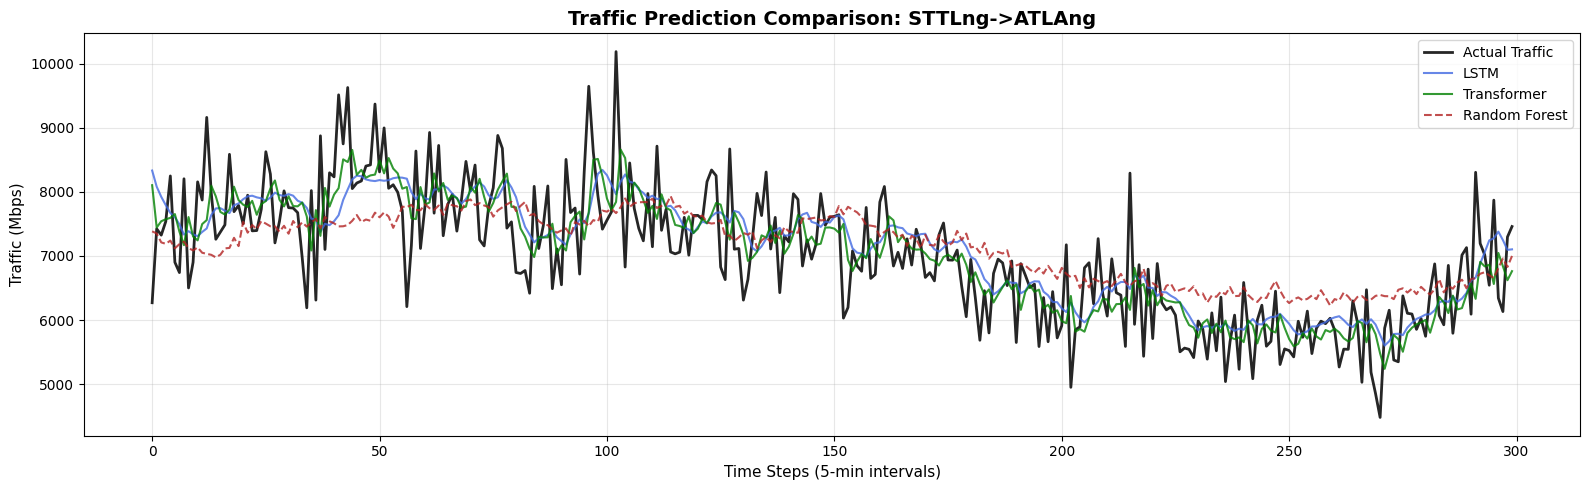


2. Median Performing Link:


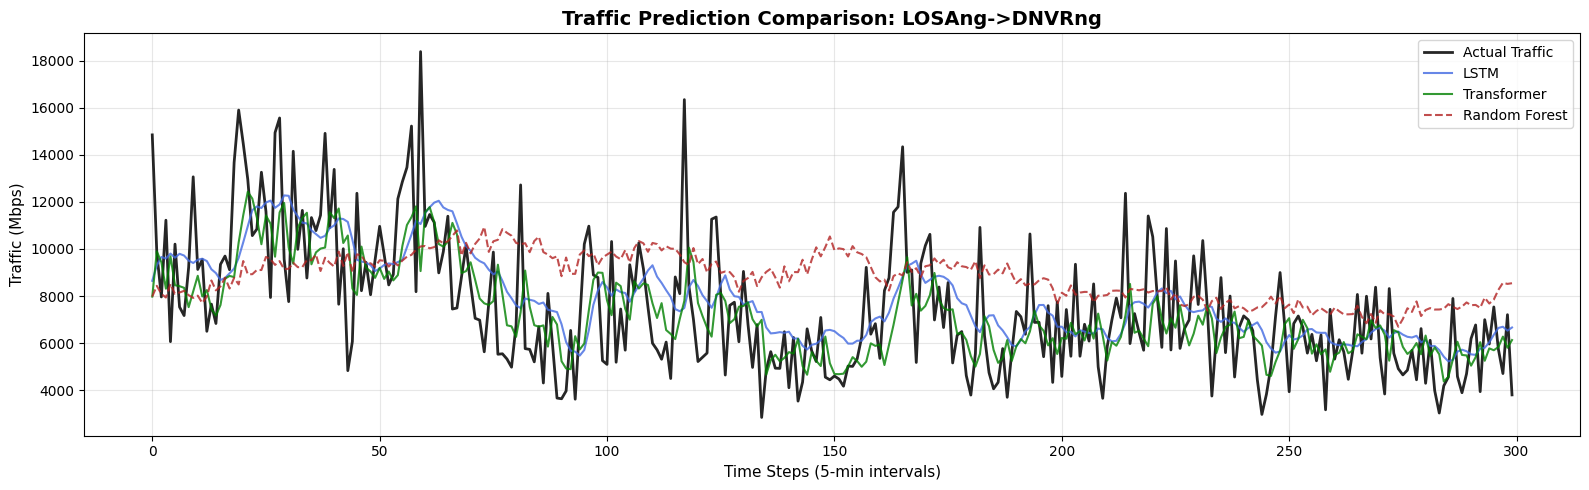


3. Worst Performing Link:


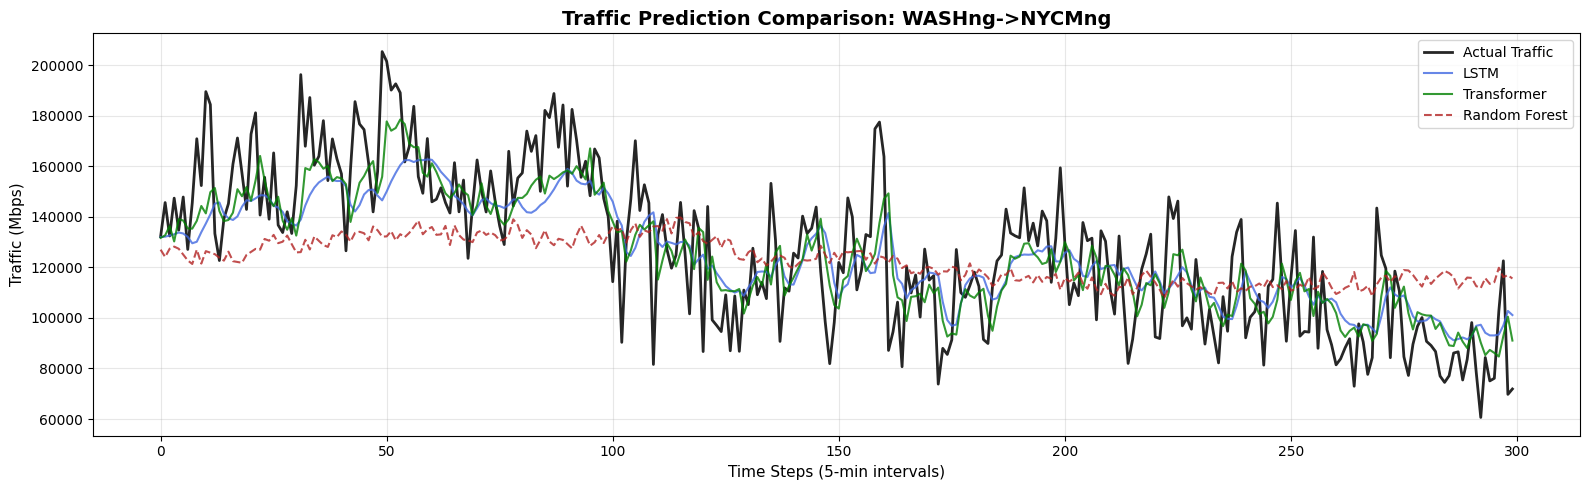

In [ ]:
# CELL 22: Visualize Representative Links
print("\n" + "="*60)
print("GENERATING VISUALIZATIONS (First 300 timesteps ≈ 25 hours)")
print("="*60)

print("\n1. Best Performing Link:")
visualize_traffic_comparison(best_link, best_idx)

print("\n2. Median Performing Link:")
visualize_traffic_comparison(median_link, median_idx)

print("\n3. Worst Performing Link:")
visualize_traffic_comparison(worst_link, worst_idx)

In [ ]:
# CELL 23: Model Comparison Summary Statistics
print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)

summary_stats = pd.DataFrame({
    'Model': ['LSTM', 'Transformer', 'Random Forest'],
    'Mean RMSE': [comp_df['lstm_rmse'].mean(), comp_df['transformer_rmse'].mean(), comp_df['rf_rmse'].mean()],
    'Median RMSE': [comp_df['lstm_rmse'].median(), comp_df['transformer_rmse'].median(), comp_df['rf_rmse'].median()],
    'Std RMSE': [comp_df['lstm_rmse'].std(), comp_df['transformer_rmse'].std(), comp_df['rf_rmse'].std()],
    'Min RMSE': [comp_df['lstm_rmse'].min(), comp_df['transformer_rmse'].min(), comp_df['rf_rmse'].min()],
    'Max RMSE': [comp_df['lstm_rmse'].max(), comp_df['transformer_rmse'].max(), comp_df['rf_rmse'].max()],
    'Links Won': [lstm_wins, transformer_wins, rf_wins]
})

display(summary_stats)



SUMMARY STATISTICS


,Model,Mean RMSE,Median RMSE,Std RMSE,Min RMSE,Max RMSE,Links Won
0,LSTM,2516.587583,1556.800501,3244.617046,14.584536,21650.626228,7
1,Transformer,2326.532855,1458.078857,2993.130513,14.056470,17947.423540,125
2,Random Forest,4072.573461,2388.599097,5621.836722,14.854209,43147.472427,0


In [ ]:
# CELL 24: Training Time Comparison
print("\n" + "="*60)
print("ADDITIONAL ANALYSIS")
print("="*60)

# Calculate percentage improvement over baseline for each model
baseline_rmse = results.loc[results['model']=='Persistence (Baseline)', 'rmse'].values[0]

improvements = []
for model_name in ['LSTM', 'Transformer', 'Random Forest']:
    model_rmse = results.loc[results['model']==model_name, 'rmse'].values[0]
    improvement = (baseline_rmse - model_rmse) / baseline_rmse * 100
    improvements.append({
        'Model': model_name,
        'RMSE': model_rmse,
        'Improvement over Baseline (%)': improvement
    })

improvement_df = pd.DataFrame(improvements)
print("\nImprovement over Persistence Baseline:")
display(improvement_df)

# Calculate pairwise comparisons
print("\nPairwise Model Comparisons (RMSE):")
print(f"LSTM vs Transformer: {((t_rmse - l_rmse) / l_rmse * 100):+.2f}% (negative means LSTM is better)")
print(f"LSTM vs RF: {((r_rmse - l_rmse) / l_rmse * 100):+.2f}% (negative means LSTM is better)")
print(f"Transformer vs RF: {((r_rmse - t_rmse) / t_rmse * 100):+.2f}% (negative means Transformer is better)")


ADDITIONAL ANALYSIS

Improvement over Persistence Baseline:


,Model,RMSE,Improvement over Baseline (%)
0,LSTM,4096.461736,2.849732
1,Transformer,3782.025313,10.306798
2,Random Forest,6924.700032,-64.223788



Pairwise Model Comparisons (RMSE):
LSTM vs Transformer: -7.68% (negative means LSTM is better)
LSTM vs RF: +69.04% (negative means LSTM is better)
Transformer vs RF: +83.10% (negative means Transformer is better)


In [ ]:
# CELL 25: Save All Results and Generate Final Report
print("\n" + "="*60)
print("SAVING RESULTS")
print("="*60)

# Create a comprehensive report
report = {
    'Configuration': {
        'USE_LOG': USE_LOG,
        'PCA_COMPONENTS': PCA_COMPONENTS,
        'SEQ_LEN_RF': SEQ_LEN_RF,
        'SEQ_LEN_LSTM': SEQ_LEN_LSTM,
        'SEQ_LEN_TRANSFORMER': SEQ_LEN_TRANSFORMER,
        'TRAIN_RATIO': TRAIN_RATIO,
        'RF_N_ESTIMATORS': RF_N_ESTIMATORS,
        'BATCH_SIZE': BATCH_SIZE,
        'EPOCHS': EPOCHS
    },
    'Overall_Results': results.to_dict('records'),
    'Per_Link_Wins': {
        'LSTM': int(lstm_wins),
        'Transformer': int(transformer_wins),
        'RandomForest': int(rf_wins)
    },
    'Summary_Statistics': summary_stats.to_dict('records'),
    'Improvements': improvement_df.to_dict('records')
}

import json
with open(os.path.join(OUT_DIR, 'experiment_report.json'), 'w') as f:
    json.dump(report, f, indent=2)

print(f"✓ Overall comparison: {os.path.join(OUT_DIR, 'overall_comparison.csv')}")
print(f"✓ Per-link comparison: {os.path.join(OUT_DIR, 'per_link_comparison_all_models.csv')}")
print(f"✓ Summary statistics: {os.path.join(OUT_DIR, 'summary_statistics.csv')}")
print(f"✓ Experiment report: {os.path.join(OUT_DIR, 'experiment_report.json')}")
print(f"✓ Visualizations saved in: {OUT_DIR}")

print("\n" + "="*60)
print("EXPERIMENT COMPLETE!")
print("="*60)
print(f"\nBest Model: {results.iloc[0]['model']}")
print(f"Best RMSE: {results.iloc[0]['rmse']:.4f} Mbps")
print(f"Best MAE: {results.iloc[0]['mae']:.4f} Mbps")
print(f"\nAll results saved to: {OUT_DIR}")


SAVING RESULTS
✓ Overall comparison: ./figures/overall_comparison.csv
✓ Per-link comparison: ./figures/per_link_comparison_all_models.csv
✓ Summary statistics: ./figures/summary_statistics.csv
✓ Experiment report: ./figures/experiment_report.json
✓ Visualizations saved in: ./figures

EXPERIMENT COMPLETE!

Best Model: Transformer
Best RMSE: 3782.0253 Mbps
Best MAE: 1746.1567 Mbps

All results saved to: ./figures
